In [8]:
# Install Kaggle CLI
!pip install kaggle

# Upload your kaggle.json API key file (download from Kaggle → Account → API)
from google.colab import files
files.upload()  # Choose your kaggle.json file

# Create Kaggle folder and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d asthalochanmohanta/american-sign-language-asl

# Unzip the downloaded file
!unzip american-sign-language-asl.zip -d asl_dataset

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/asthalochanmohanta/american-sign-language-asl
License(s): apache-2.0
100% 3.11G/3.11G [00:34<00:00, 246MB/s]
100% 3.11G/3.11G [00:34<00:00, 96.3MB/s]
Archive:  american-sign-language-asl.zip
  inflating: asl_dataset/dataset_v2/test/again/again_asl_video_2023-12-12_12-32-39.mp4  
  inflating: asl_dataset/dataset_v2/test/again/again_asl_video_2023-12-12_12-34-48.mp4  
  inflating: asl_dataset/dataset_v2/test/again/again_asl_video_2023-12-12_12-34-59.mp4  
  inflating: asl_dataset/dataset_v2/test/again/again_asl_video_2023-12-12_12-37-29.mp4  
  inflating: asl_dataset/dataset_v2/test/again/again_asl_video_2023-12-12_12-38-50.mp4  
  inflating: asl_dataset/dataset_v2/test/again/again_asl_video_2023-12-12_12-39-40.mp4  
  inflating: asl_dataset/dataset_v2/test/again/again_asl_video_2023-12-12_12-39-54.mp4  
  inflating: asl_dataset/dataset_v2/test/again/again_asl_video_2023-12-12_12-40-25.mp4  
  inflating: asl_d

In [9]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from tensorflow.keras.applications.efficientnet import preprocess_input

# Input directories (update with Kaggle paths when running on Kaggle)
data_dirs = {
    'train': "/content/asl_dataset/dataset_v2/train",
    'val': "/content/asl_dataset/dataset_v2/val",
    'test': "/content/asl_dataset/dataset_v2/test"
}

# Output (processed) directory
target_root = "/kaggle/working/asl_frames_processed"
os.makedirs(target_root, exist_ok=True)

# Settings
TARGET_FRAMES = 12  # Reduced for faster training and lower memory usage
RESIZE_SHAPE = (224, 224)  # EfficientNetB0 expected input size

In [10]:
def extract_and_save_frames(video_path, output_dir, target_frames=TARGET_FRAMES, resize=RESIZE_SHAPE):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < 10:
        target_frames = min(8, total_frames)

    if total_frames <= target_frames:
        indices = np.arange(total_frames)
    else:
        start_frame = int(total_frames * 0.1)
        end_frame = int(total_frames * 0.9)
        effective_range = end_frame - start_frame

        if effective_range < target_frames:
            indices = np.linspace(start_frame, end_frame - 1, num=target_frames, dtype=int)
        else:
            weights = np.concatenate([
                np.linspace(0.3, 1, effective_range // 2),
                np.linspace(1, 0.3, effective_range - effective_range // 2)
            ])
            weights /= weights.sum()

            indices = np.sort(np.random.choice(
                np.arange(start_frame, end_frame),
                size=target_frames,
                replace=False,
                p=weights
            ))

    os.makedirs(output_dir, exist_ok=True)
    frame_count = 0

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, resize)

            # === Augmentations ===

            # Illumination change (brightness + contrast adjustment)
            if np.random.rand() < 0.5:
                alpha = np.random.uniform(0.2, 1.5)  # contrast
                beta = np.random.randint(-40, 40)   # brightness
                frame = np.clip(alpha * frame + beta, 0, 255).astype(np.uint8)

            # Gaussian noise
            if np.random.rand() < 0.5:
                noise = np.random.normal(0, 10, frame.shape).astype(np.int16)
                frame = np.clip(frame.astype(np.int16) + noise, 0, 255).astype(np.uint8)

            # Gaussian blur
            if np.random.rand() < 0.5:
                ksize = np.random.choice([3, 5])
                frame = cv2.GaussianBlur(frame, (ksize, ksize), 0)

            # =====================

            filename = f"{os.path.basename(video_path).split('.')[0]}_frame_{frame_count}.jpg"
            save_path = os.path.join(output_dir, filename)
            cv2.imwrite(save_path, cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
            frame_count += 1

    cap.release()

In [11]:
# Main processing loop to extract frames from all videos
for split_name, data_path in data_dirs.items():
    for label_name in tqdm(os.listdir(data_path), desc=f"Processing {split_name}"):
        label_path = os.path.join(data_path, label_name)
        if not os.path.isdir(label_path):
            continue

        for video_file in os.listdir(label_path):
            if video_file.lower().endswith(('.mp4', '.avi', '.mov')):
                video_path = os.path.join(label_path, video_file)
                out_dir = os.path.join(target_root, split_name, label_name)
                extract_and_save_frames(video_path, out_dir)

Processing test: 100%|██████████| 47/47 [01:18<00:00,  1.66s/it]


In [12]:
from tensorflow.keras.utils import Sequence
import cv2
import os
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

# Base class
class FrameSequenceGenerator(Sequence):
    def __init__(self, data_dir, label_encoder, batch_size=4, frames_per_video=12, shuffle=True):
        self.data_dir = data_dir
        self.label_encoder = label_encoder
        self.batch_size = batch_size
        self.frames_per_video = frames_per_video
        self.shuffle = shuffle
        self.data = self._load_video_frame_paths()
        self.on_epoch_end()

    def _load_video_frame_paths(self):
        data = []
        for label in os.listdir(self.data_dir):
            label_path = os.path.join(self.data_dir, label)
            for filename in os.listdir(label_path):
                video_prefix = "_".join(filename.split("_")[:-2])
                video_path = os.path.join(label_path, video_prefix)
                if video_path not in [v[0] for v in data]:
                    data.append((video_path, label))
        return data

    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.data)

    def __getitem__(self, index):
        batch_data = self.data[index * self.batch_size:(index + 1) * self.batch_size]
        X, y = [], []

        for video_path, label in batch_data:
            frames = self._load_video_frames(video_path, label)
            if frames is not None:
                X.append(frames)
                y.append(self.label_encoder.transform([label])[0])

        return np.array(X), np.array(y)

    def _load_video_frames(self, video_base_path, label):
        frames = []
        label_path = os.path.join(self.data_dir, label)
        frame_files = sorted([
            f for f in os.listdir(label_path)
            if f.startswith(os.path.basename(video_base_path)) and f.endswith('.jpg')
        ])

        if len(frame_files) < self.frames_per_video:
            return None

        for f in frame_files[:self.frames_per_video]:
            frame_path = os.path.join(label_path, f)
            img = cv2.imread(frame_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            img = preprocess_input(img)
            frames.append(img)

        return np.array(frames)

# Subclass with manual augmentation
class AugmentedFrameSequenceGenerator(FrameSequenceGenerator):
    def __init__(self, data_dir, label_encoder, batch_size=4, frames_per_video=12, shuffle=True, augmentation=True):
        super().__init__(data_dir, label_encoder, batch_size, frames_per_video, shuffle)
        self.augmentation = augmentation

    def _load_video_frames(self, video_base_path, label):
        frames = []
        label_path = os.path.join(self.data_dir, label)
        frame_files = sorted([
            f for f in os.listdir(label_path)
            if f.startswith(os.path.basename(video_base_path)) and f.endswith('.jpg')
        ])

        if len(frame_files) < self.frames_per_video:
            return None

        for f in frame_files[:self.frames_per_video]:
            frame_path = os.path.join(label_path, f)
            img = cv2.imread(frame_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))

            if self.augmentation:
                # Illumination (brightness/contrast)
                if np.random.rand() < 0.5:
                    alpha = np.random.uniform(0.2, 1.5)
                    beta = np.random.randint(-40, 40)
                    img = np.clip(alpha * img + beta, 0, 255).astype(np.uint8)

                # Gaussian noise
                if np.random.rand() < 0.5:
                    noise = np.random.normal(0, 30, img.shape).astype(np.int16)
                    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

                # Gaussian blur
                if np.random.rand() < 0.5:
                    ksize = np.random.choice([3, 5])
                    img = cv2.GaussianBlur(img, (ksize, ksize), 0)

            img = preprocess_input(img)
            frames.append(img)

        return np.array(frames)

In [13]:
from sklearn.preprocessing import LabelEncoder
import os

# No longer needed — augmentation is done manually, so remove this:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths to your processed frames on Kaggle
train_dir = "/kaggle/working/asl_frames_processed/train"
val_dir = "/kaggle/working/asl_frames_processed/val"
test_dir = "/kaggle/working/asl_frames_processed/test"

# Extract class names and encode them
class_names = sorted(os.listdir(train_dir))
label_encoder = LabelEncoder()
label_encoder.fit(class_names)

# Augmented generators (illumination + noise + blur applied manually inside class)
train_gen_augmented = AugmentedFrameSequenceGenerator(train_dir, label_encoder, batch_size=4)
val_gen_augmented = AugmentedFrameSequenceGenerator(val_dir, label_encoder, batch_size=4)
test_gen_augmented = AugmentedFrameSequenceGenerator(test_dir, label_encoder, batch_size=4, shuffle=False)

In [14]:
import random
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np

def apply_custom_augmentations(img):
    # Illumination (brightness/contrast)
    if np.random.rand() < 0.5:
        alpha = np.random.uniform(0.2, 1.5)
        beta = np.random.randint(-40, 40)
        img = np.clip(alpha * img + beta, 0, 255).astype(np.uint8)

    # Gaussian noise
    if np.random.rand() < 0.5:
        noise = np.random.normal(0, 30, img.shape).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Gaussian blur
    if np.random.rand() < 0.5:
        ksize = np.random.choice([3, 5])
        img = cv2.GaussianBlur(img, (ksize, ksize), 0)

    return img

def visualize_random_video_frames(processed_dir, label_encoder, frames_per_video=12, augmented=False):
    # Pick a random class
    class_name = random.choice(os.listdir(processed_dir))
    class_path = os.path.join(processed_dir, class_name)

    # Pick a random video prefix
    video_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    video_prefixes = list(set("_".join(f.split("_")[:-2]) for f in video_files))

    if not video_prefixes:
        print("⚠️ No video frames found in this class.")
        return

    video_prefix = random.choice(video_prefixes)

    # Gather all frames for the selected video
    frame_files = sorted([
        f for f in video_files if f.startswith(video_prefix)
    ])[:frames_per_video]

    frames = []
    augmented_frames = []

    for frame_file in frame_files:
        img_path = os.path.join(class_path, frame_file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            frames.append(img)

            if augmented:
                aug_img = apply_custom_augmentations(img.copy())
                augmented_frames.append(aug_img)

    if not frames:
        print("⚠️ No frames could be read from video:", video_prefix)
        return

    plt.figure(figsize=(15, 5))

    for i, idx in enumerate([0, len(frames)//2, len(frames)-1]):
        plt.subplot(2, 3, i + 1)  # First row (original)
        plt.imshow(frames[idx])
        plt.title(f"Original Frame {idx} — Class: {class_name}")
        plt.axis('off')

        if augmented:
            plt.subplot(2, 3, i + 4)  # Second row (augmented)
            plt.imshow(augmented_frames[idx])
            plt.title(f"Augmented Frame {idx} — Class: {class_name}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

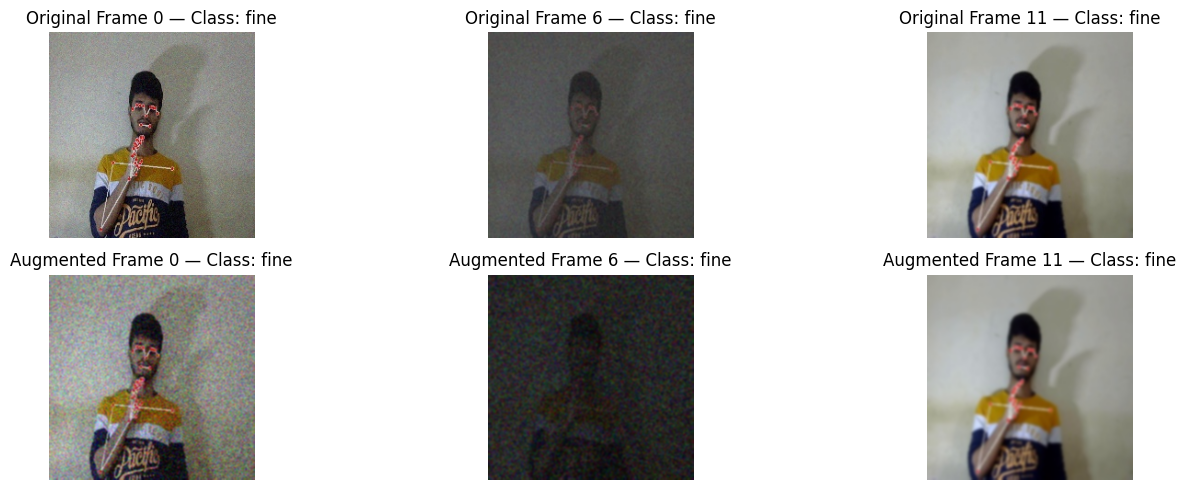

In [15]:
visualize_random_video_frames(train_dir, label_encoder, augmented=True)

In [16]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, TimeDistributed, LSTM, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Define input: (batch, time, height, width, channels)
input_shape = (12, 224, 224, 3)
input_layer = Input(shape=input_shape)

# Load EfficientNetB0 (without top)
cnn = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Option to fine-tune EfficientNetB0 by unfreezing the last few layers (optional)
for layer in cnn.layers[-30:]:  # Fine-tune the last 30 layers (or adjust as needed)
    layer.trainable = True

# Apply CNN to each frame
x = TimeDistributed(cnn)(input_layer)
x = TimeDistributed(GlobalAveragePooling2D())(x)

# LSTM over time
x = LSTM(128, return_sequences=False)(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 12, 7, 7, 1280) │     4,049,571 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 12, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,816,082 (18.37 MB)

 Trainable params: 4,774,059 (18.21 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(
        monitor='val_accuracy',     # Track validation accuracy
        factor=0.5,                 # Reduce learning rate by half
        patience=3,                 # Wait 3 epochs of no improvement
        min_lr=1e-6,                # Never go below this learning rate
        verbose=1
    )
]

# Training with dynamic learning rate and early stopping
history = model.fit(
    train_gen_augmented,
    validation_data=val_gen_augmented,
    epochs=9,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/9
713/713 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.1166 - loss: 3.2912

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


713/713 ━━━━━━━━━━━━━━━━━━━━ 854s 871ms/step - accuracy: 0.1167 - loss: 3.2905 - val_accuracy: 0.3921 - val_loss: 1.7853 - learning_rate: 0.0010
Epoch 2/9
713/713 ━━━━━━━━━━━━━━━━━━━━ 568s 797ms/step - accuracy: 0.3635 - loss: 1.8258 - val_accuracy: 0.6377 - val_loss: 1.0801 - learning_rate: 0.0010
Epoch 3/9
713/713 ━━━━━━━━━━━━━━━━━━━━ 586s 822ms/step - accuracy: 0.5659 - loss: 1.1986 - val_accuracy: 0.7097 - val_loss: 0.7368 - learning_rate: 0.0010
Epoch 4/9
713/713 ━━━━━━━━━━━━━━━━━━━━ 570s 799ms/step - accuracy: 0.7035 - loss: 0.7957 - val_accuracy: 0.8809 - val_loss: 0.3751 - learning_rate: 0.0010
Epoch 5/9
713/713 ━━━━━━━━━━━━━━━━━━━━ 566s 794ms/step - accuracy: 0.8113 - loss: 0.5359 - val_accuracy: 0.8586 - val_loss: 0.3786 - learning_rate: 0.0010
Epoch 6/9
713/713 ━━━━━━━━━━━━━━━━━━━━ 565s 792ms/step - accuracy: 0.8720 - loss: 0.4006 - val_accuracy: 0.9603 - val_loss: 0.1482 - learning_rate: 0.0010
Epoch 7/9
713/713 ━━━━━━━━━━━━━━━━━━━━ 567s 796ms/step - accuracy: 0.9190 - loss

In [18]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_gen_augmented, verbose=1)

# Print test results
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 236ms/step - accuracy: 0.9572 - loss: 0.1664
Test Loss: 0.19581234455108643
Test Accuracy: 0.9431137442588806


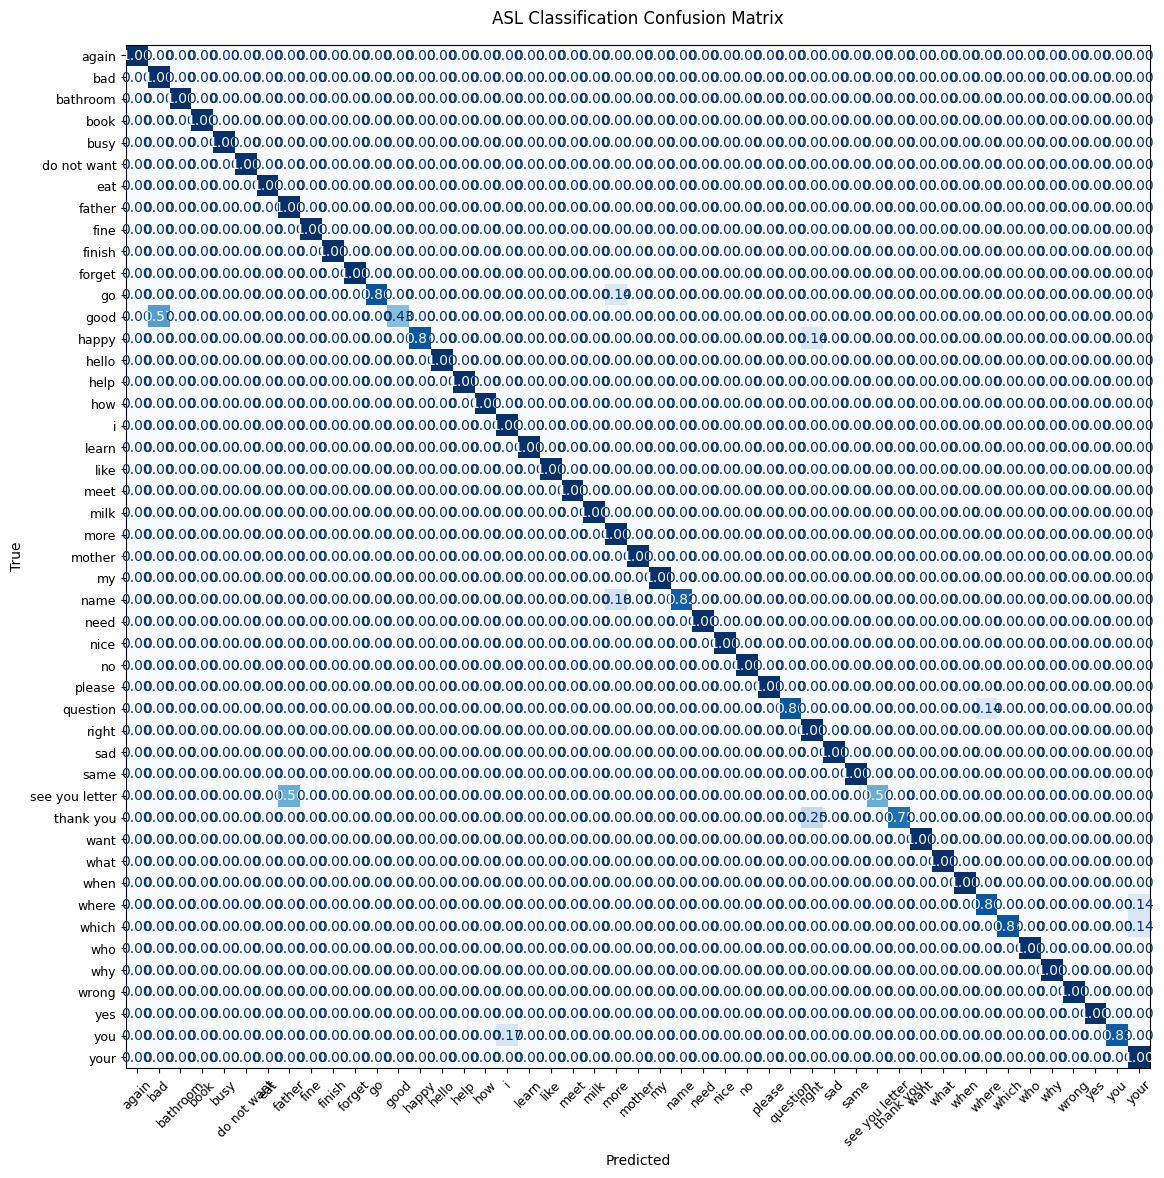

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
y_true = []
y_pred = []
for i in range(len(test_gen_augmented)):
    X_batch, y_batch = test_gen_augmented[i]
    y_true.extend(y_batch)
    y_pred.extend(np.argmax(model.predict(X_batch, verbose=0), axis=1))

# Generate confusion matrix (normalized)
cm = confusion_matrix(y_true, y_pred, normalize='true')

# Optimized plot size
plt.figure(figsize=(15, 12))  # Reduced from 20x20
ax = plt.gca()

# Plot with adjusted formatting
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=label_encoder.classes_)
disp.plot(ax=ax,
         cmap='Blues',
         values_format='.2f',
         xticks_rotation=45,  # Less aggressive rotation
         colorbar=False)

# Improved text sizing
plt.xticks(fontsize=9)  # Slightly smaller
plt.yticks(fontsize=9)
plt.xlabel('Predicted', fontsize=10)
plt.ylabel('True', fontsize=10)
plt.title('ASL Classification Confusion Matrix', fontsize=12, pad=15)

# Smart layout adjustment
plt.tight_layout(pad=1.5)  # Less padding than default
plt.show()

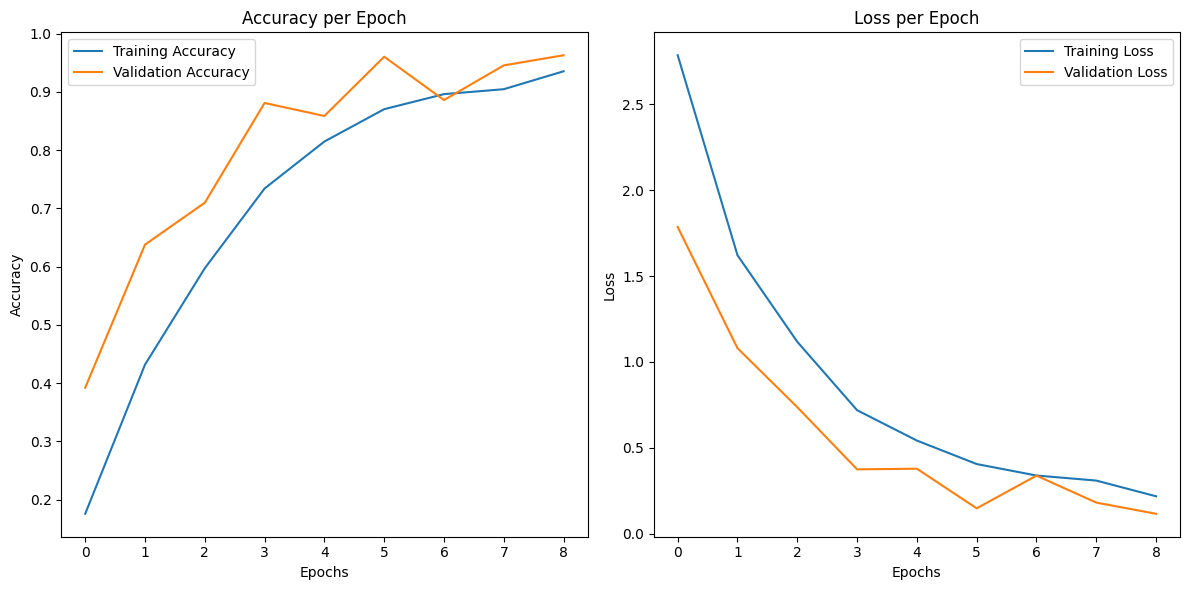

In [20]:
import matplotlib.pyplot as plt

# Plotting Accuracy per Epochs
plt.figure(figsize=(12, 6))

# Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting Loss per Epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
model.save("asl_model_efficientnetb000.h5")
print("✅ Model saved as 'asl_model_efficientnetb000.h5'")

✅ Model saved as 'asl_model_efficientnetb000.h5'


In [25]:
from google.colab import files
files.download('asl_model_efficientnetb000.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# prompt: evaluate precision , recall and f1 score

from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1-score
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Precision: 0.9631
Recall: 0.9461
F1-score: 0.9455
